In [1]:
import os

os.environ["KERAS_BACKEND"] = "torch"  # Or "jax" / "torch"

import keras
from dataclasses import dataclass
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
import time
fhvhv = True

In [2]:
import torch

# Check if CUDA is available
is_available = torch.cuda.is_available()
if is_available:
    # Print the name of the AMD GPU
    print(f"Device name: {torch.cuda.get_device_name(0)}")
    
    # Perform a test tensor allocation on the GPU
    t = torch.tensor([1, 2, 3], device='cuda')
    print(f"Test tensor successfully placed on: {t.device}")
else:
    print("GPU not detected. PyTorch will run on CPU.")


Device name: AMD Radeon RX 9070 XT
Test tensor successfully placed on: cuda:0


In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
projectRoot = Path.cwd().parents[2]
dataPath = Path(projectRoot, 
                "data/raw/") # Replace with the path of your data
taxiPath = Path(dataPath, "tlc_trip_record/yellow/")
weatherPath = Path(dataPath, "weather/")
lookUpPath = Path(projectRoot, "data/NYC_Taxi_Zones_20251203.csv")

In [4]:
from dataclasses import dataclass
@dataclass
class dates:
    start_year: int
    start_month: int
    end_year: int
    end_month: int
train_dates = dates(2025,1,2026,1)
val_dates = dates(2025,7, 2025,10)

In [5]:
from dataset.taxi_demand import TaxiDemand, FHVHVTaxiDemand
def get_taxiDemand(date: dates):
    if fhvhv:
        return FHVHVTaxiDemand(date.start_year, date.start_month, date.end_year, date.end_month)
    else:
        return TaxiDemand(date.start_year, date.start_month, date.end_year, date.end_month)

In [6]:
input_steps = 12
target_index = 0
train = get_taxiDemand(train_dates)
val = get_taxiDemand(val_dates)

feature_list = ['pickups', 'precipitation', 'wind_speed_10m', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos']

data_train = train.prepare_dataset(feature_list)
X_train, Y_train = train.construct_dataset(data_train, input_steps, target_index)

data_val = val.prepare_dataset(feature_list)
X_val, Y_val = val.construct_dataset(data_val, input_steps, target_index)

 # Usando solo capas fully connected

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
checkpoint = ModelCheckpoint(
            filepath="dense.keras", 
            monitor="val_loss", 
            save_best_only=True, 
            verbose=0
            )
# Reduce learning rate by half if validation loss plateaus for 4 epochs
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=8, 
    min_lr=1e-6, 
    verbose=0
)

callbacks = [checkpoint, lr_scheduler]
import keras.layers as layers
from keras.models import Sequential
import keras
def create_dense_baseline():
    x_in = layers.Input(
        shape=(263, len(feature_list) - 1),
        name="features",
    )

    x = layers.Flatten()(x_in)
    for i in [16,32,64,128,256,512,1024]:
         x = layers.Dense(i, activation= "relu")(x)
    out = layers.Dense(263, activation= "relu")(x)
    model = keras.Model(inputs=x_in, outputs=out, name="Dense")
    return model

dense_model = create_dense_baseline()
dense_model.compile(optimizer='adam', loss='mse')
t_0 = time.time()
history_dense = dense_model.fit(data_train[:,:,1:], data_train[:,:,0], validation_data=(data_val[:,:,1:], data_val[:,:,0]), callbacks=callbacks ,epochs= 100)
t_1 = time.time()
time_dense = t_1 - t_0

Epoch 1/100
127/136 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2424.4776

I0000 00:00:1777195589.376458   14064 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777195589.380103   14064 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777195589.767922   14064 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


136/136 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 1740.2444 - val_loss: 973.0573 - learning_rate: 0.0010
Epoch 2/100
 15/136 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1039.9608

I0000 00:00:1777195590.536421   14064 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777195590.538753   14064 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 866.7356 - val_loss: 733.8450 - learning_rate: 0.0010
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 764.9775 - val_loss: 661.7307 - learning_rate: 0.0010
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 711.9807 - val_loss: 648.1221 - learning_rate: 0.0010
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 704.2123 - val_loss: 614.6676 - learning_rate: 0.0010
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 674.5437 - val_loss: 585.8732 - learning_rate: 0.0010
Epoch 7/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 458.0968 - val_loss: 400.0836 - learning_rate: 0.0010
Epoch 8/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 302.1499 - val_loss: 385.2027 - learning_rate: 0.0010
Epoch 9/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 293.6986 - val_loss: 326.8181 - learning_rate: 0.0010
Epoch 10/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 298.8849 - val_loss: 393.6389 

In [ ]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from keras import layers
checkpoint = ModelCheckpoint(
            filepath="rnn.keras", 
            monitor="val_loss", 
            save_best_only=True, 
            verbose=0
            )

# Reduce learning rate by half if validation loss plateaus for 4 epochs
lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss", 
    factor=0.5, 
    patience=8, 
    min_lr=1e-6, 
    verbose=0
)

callbacks = [checkpoint, lr_scheduler]

def create_rnn_d():
    n_features = len(feature_list)
    x_in = layers.Input(shape=(input_steps, 263, n_features))
    x = layers.Reshape((input_steps,263 * n_features))(x_in)
    x = layers.LSTM(256, activation= "relu", return_sequences= False)(x)
    out = layers.Dense(263, activation="relu")(x)
    
    model = keras.Model(inputs=x_in, outputs=out, name="LSTM")
    return model

rnn_model = create_rnn_d()
rnn_model.compile(optimizer='adam', loss='mse')
t_0 = time.time()
history_rnn = rnn_model.fit(X_train, Y_train, batch_size= 32, validation_data=(X_val, Y_val), callbacks= callbacks, epochs= 100)
t_1 = time.time()
time_rnn = t_1 - t_0

Epoch 1/100
129/136 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2740.9662

I0000 00:00:1777199586.553539   23907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777199586.553816   23907 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777199586.573524   23907 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


136/136 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1598.1252 - val_loss: 485.9103 - learning_rate: 0.0010
Epoch 2/100
 30/136 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 508.9041

I0000 00:00:1777199587.033063   23907 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777199587.033224   23907 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 453.7275 - val_loss: 397.7714 - learning_rate: 0.0010
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 340.4314 - val_loss: 292.6510 - learning_rate: 0.0010
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 295.6730 - val_loss: 275.2217 - learning_rate: 0.0010
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 273.8341 - val_loss: 265.7401 - learning_rate: 0.0010
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 256.6103 - val_loss: 251.3158 - learning_rate: 0.0010
Epoch 7/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 250.5646 - val_loss: 241.1289 - learning_rate: 0.0010
Epoch 8/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 234.5020 - val_loss: 228.8321 - learning_rate: 0.0010
Epoch 9/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 228.0448 - val_loss: 226.5534 - learning_rate: 0.0010
Epoch 10/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 222.9668 - val_loss: 219.5345 

In [ ]:
from model_stgcn import build_stgcn
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.losses import MeanSquaredError
import gc
in_channels = data_train.shape[2]
num_nodes = 263
model_path = "stgcn_fhvh.keras"
stgcn_model = build_stgcn(
    num_nodes=num_nodes,
    in_channels=in_channels,
    time_steps=input_steps,
    residual= True,
    drop_out = 0.3,
    hidden_channels=256,
    kernel_size=3,
    num_blocks=2,
)
stgcn_model.compile(
    optimizer= "adam",
    loss="mse"
)

class ClearMemoryCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
clear_memory = ClearMemoryCallback()
checkpoint = ModelCheckpoint(
            filepath=model_path, 
            monitor="loss", 
            save_best_only=True, 
            verbose=0
            )
# Reduce learning rate by half if validation loss plateaus for 5 epochs
lr_scheduler = ReduceLROnPlateau(
    monitor="loss", 
    factor=0.5, 
    patience=8, 
    min_lr=1e-6, 
    verbose=0
)
callbacks = [clear_memory, checkpoint, lr_scheduler]
t_0 = time.time()
history_stgcn = stgcn_model.fit(
    X_train, Y_train,
    batch_size=32,
    epochs=100,
    #validation_data=(X_val, Y_val),
    callbacks = callbacks
)
t_1 = time.time()
time_stgcn = t_1 - t_0

I0000 00:00:1777471486.072749   18715 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777471486.076551   18715 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777471486.470436   18715 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Epoch 1/100


I0000 00:00:1777471487.297184   18715 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777471487.299505   18715 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 175ms/step - loss: 385.7305 - learning_rate: 0.0010
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 173ms/step - loss: 219.5654 - learning_rate: 0.0010
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 174ms/step - loss: 184.9585 - learning_rate: 0.0010
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - loss: 161.7860 - learning_rate: 0.0010
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - loss: 150.0979 - learning_rate: 0.0010
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - loss: 142.5642 - learning_rate: 0.0010
Epoch 7/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - loss: 137.4475 - learning_rate: 0.0010
Epoch 8/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - loss: 134.2856 - learning_rate: 0.0010
Epoch 9/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 176ms/step - loss: 129.7769 - learning_rate: 0.0010
Epoch 10/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 48s 175ms/step - loss: 127.1115 - learning_rate: 0.0010
Epoch 11/100
274/274 ━━━━━━━━━━━━━━━━━━━━

In [11]:
pd.DataFrame(history_dense.history).to_csv(f"dense_history.csv", index=False)
pd.DataFrame(history_rnn.history).to_csv(f"rnn_history.csv", index=False)
pd.DataFrame(history_stgcn.history).to_csv(f"stgcn_history.csv", index=False)

In [12]:
print("Tiempo de entrenamiento")
print(f"\t Dense: {time_dense}")
print(f"\t RNN: {time_rnn}")
print(f"\t STGCN: {time_stgcn}")

Tiempo de entrenamiento
	 Dense: 67.45331883430481
	 RNN: 95.11637020111084
	 STGCN: 2729.1850407123566


In [16]:
import pandas as pd

# 1. Cargar el historial que guardaste durante el entrenamiento
hist_df = pd.read_csv("dense_history.csv")

# 2. Encontrar la fila (epoch) donde el val_loss fue el más bajo
# idxmin() devuelve el índice de la fila con el valor mínimo
best_epoch_idx = hist_df['val_loss'].idxmin()

# 3. Extraer todas las métricas de esa fila
best_metrics = hist_df.iloc[best_epoch_idx]

print(f"El mejor epoch fue el: {best_epoch_idx + 1}") # +1 porque los índices empiezan en 0
print("\nMétricas en ese epoch:")
print(f"Train Loss (MSE): {best_metrics['loss']:.4f}")
print(f"Val Loss (MSE): {best_metrics['val_loss']:.4f}")

# Si tenías otras métricas compiladas (como MAE), también puedes imprimirlas:
# print(f"Val MAE: {best_metrics['val_mae']:.4f}")

El mejor epoch fue el: 41

Métricas en ese epoch:
Train Loss (MSE): 220.4799
Val Loss (MSE): 275.0810


In [17]:
import matplotlib.pyplot as plt

def plot_learning_curves(histories, labels=None, start_epoch=0, y_limit=None, save_path="learning_curves_comparison.png"):
    """
    Plots loss learning curves for multiple Keras model history objects.
    Displays individual plots on top (full history, auto-scaled) and a combined 
    validation loss plot on the bottom (sliced from start_epoch, using y_limit if provided).

    Args:
        histories (list): A list of 3 history objects returned by model.fit().
        labels (list): A list of strings to label the 3 models (optional).
        start_epoch (int): Epoch index to start plotting from for the BOTTOM comparison plot. 
        y_limit (tuple): A tuple (y_min, y_max) to fix the Y-axis scale on the bottom comparison plot.
        save_path (str): File path to save the generated image.
    """
    if labels is None:
        # Default labels if none are provided
        labels = [f"Model {i+1}" for i in range(len(histories))]
        
    # Create a figure with a custom grid (2 rows, 3 columns)
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.2], hspace=0.3)

    # Top row: 3 individual subplots (Independent Y-axes)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[0, 2])
    axes_top = [ax1, ax2, ax3]
    
    # Bottom row: 1 large subplot spanning all 3 columns
    ax_bottom = fig.add_subplot(gs[1, :])

    # Distinct colors for the bottom comparison plot
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] # Matplotlib's standard Blue, Orange, Green

    for i, (history, label) in enumerate(zip(histories, labels)):
        try:
            hist = history.history
        except:
            hist = history
        
        # --- Full Data for Top Row ---
        train_loss_full = hist['loss']
        epochs_full = range(1, len(train_loss_full) + 1)

        # --- Top Row: Individual Loss Curves (Start at Epoch 0) ---
        axes_top[i].plot(epochs_full, train_loss_full, 'b-o', linewidth=2, markersize=4, label='Train Loss')
        
        if 'val_loss' in hist:
            val_loss_full = hist['val_loss']
            axes_top[i].plot(epochs_full, val_loss_full, 'r-o', linewidth=2, markersize=4, label='Val Loss')
            
            # --- Sliced Data for Bottom Row (Uses start_epoch) ---
            val_loss_sliced = hist['val_loss'][start_epoch:]
            epochs_sliced = range(start_epoch + 1, len(hist['loss']) + 1)
            
            # --- Bottom Row: Big Comparison Plot (Val Loss Only, Sliced) ---
            ax_bottom.plot(epochs_sliced, val_loss_sliced, marker='o', color=colors[i % len(colors)], 
                           linewidth=2.5, markersize=5, label=f'{label} (Val Loss)')
            
        axes_top[i].set_title(f'{label}', fontsize=14, fontweight='bold')
        axes_top[i].set_xlabel('Epoch')
        axes_top[i].set_ylabel('Loss (MSE)')
        axes_top[i].legend()
        axes_top[i].grid(True, linestyle='--', alpha=0.6)

    # --- Formatting the Bottom Plot ---
    if y_limit is not None:
        ax_bottom.set_ylim(y_limit)
        
    ax_bottom.set_title('Validation Loss Comparison (Zoomed In)', fontsize=16, fontweight='bold')
    ax_bottom.set_xlabel('Epoch', fontsize=12)
    ax_bottom.set_ylabel('Loss (MSE)', fontsize=12)
    ax_bottom.legend(fontsize=12, loc='upper right')
    ax_bottom.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle('Model Learning Curves Comparison', fontsize=18, fontweight='bold', y=0.96)
    
    # Save the image before displaying it
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.show()

In [18]:
import pandas as pd

# Load the history CSV
history_dense = pd.read_csv("dense_history.csv")
history_rnn = pd.read_csv("rnn_history.csv")
history_stgcn = pd.read_csv("stgcn_history.csv")

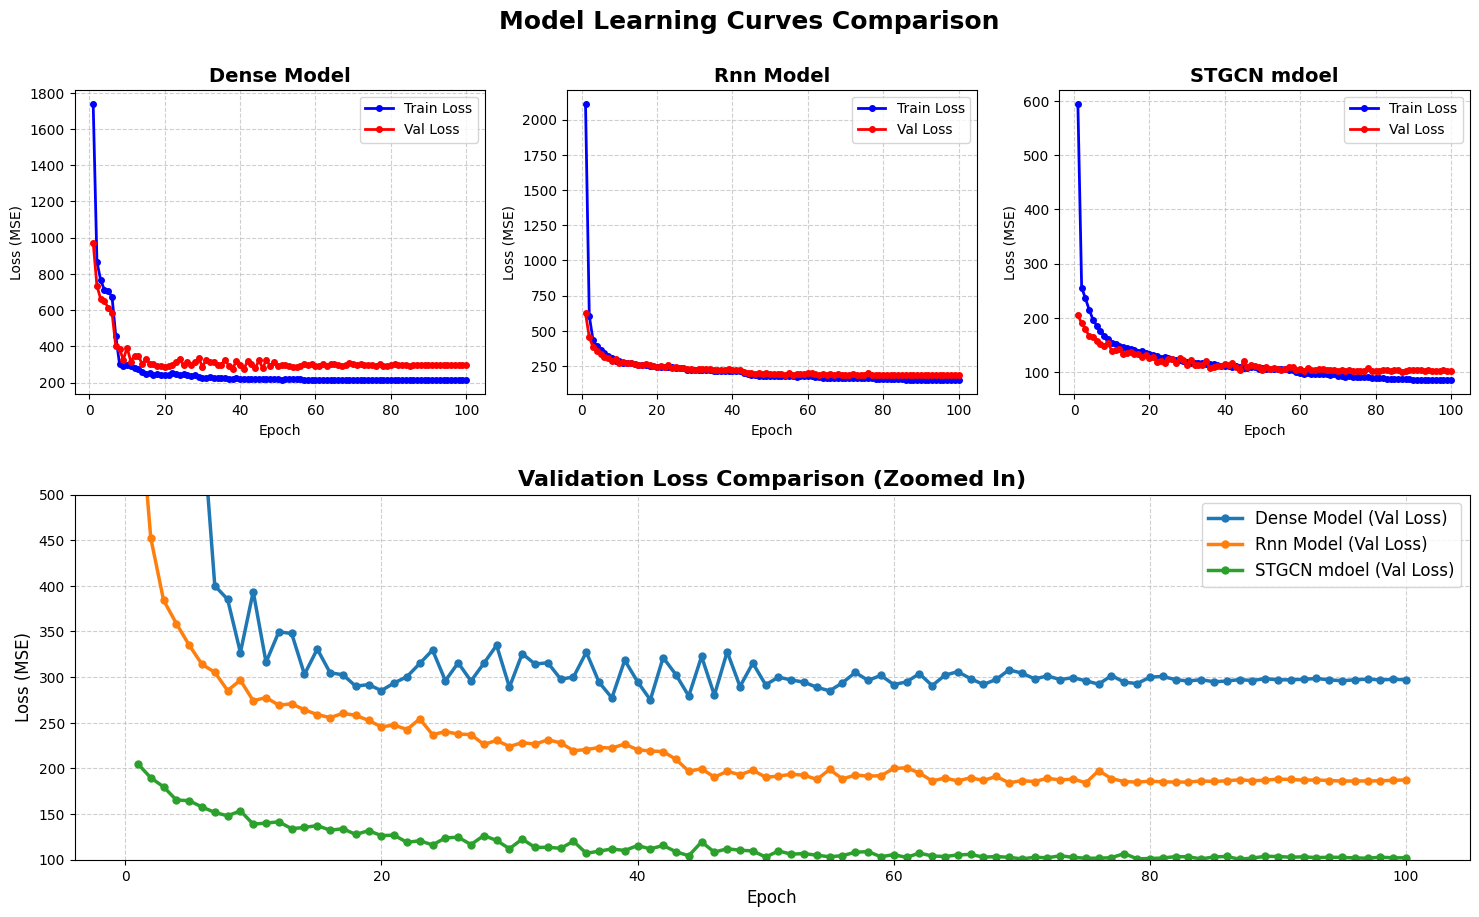

In [19]:
# Assuming you have 3 trained models
histories_list = [history_dense, history_rnn, history_stgcn]
model_names = ["Dense Model", "Rnn Model", "STGCN mdoel"]

plot_learning_curves(
    histories=histories_list,
    labels=model_names,
    start_epoch=0,          # Skips epochs 1 through 5
    y_limit=(100, 500),     # Locks the Y-axis across all 4 plots
    save_path="final_comparison.png"
)